<a href="https://colab.research.google.com/github/arikinhafln/data-analytics-activities/blob/main/challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# ***challenge1-Data-Science***

---



---

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

df_completo = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)
df_completo['Faturamento Total'] = df_completo['Preço']

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


1. *Análise* *do* *faturamento*

In [ ]:
faturamento_por_loja = df_completo.groupby('Loja')['Faturamento Total'].sum()
print("Faturamento total por loja:")
print(faturamento_por_loja.map('{:,.0f}'.format))

Faturamento total por loja:
Loja
Loja 1    1,616,347
Loja 2    1,567,773
Loja 3    1,542,048
Loja 4    1,458,253
Name: Faturamento Total, dtype: object


2.*Vendas* *por* *Categoria*

In [ ]:
faturamento_por_categoria = df_completo.groupby('Categoria do Produto')['Faturamento Total'].sum()
print("Venda de cada categoria:")
print(faturamento_por_categoria.map('{:,.0f}'.format))

Venda de cada categoria:
Categoria do Produto
brinquedos                 103,502
eletrodomesticos         1,860,199
eletronicos              2,332,048
esporte e lazer            200,892
instrumentos musicais      489,701
livros                      53,007
moveis                   1,064,150
utilidades domesticas       80,922
Name: Faturamento Total, dtype: object


3.*Média* *de* *Avaliação* *das* *Lojas*

In [ ]:
media_avaliacao_por_loja = df_completo.groupby('Loja')['Avaliação da compra'].mean()
print("Média das Avaliações por loja:")
print(media_avaliacao_por_loja.map('{:.2f}'.format))

Média das Avaliações por loja:
Loja
Loja 1    3.98
Loja 2    4.04
Loja 3    4.05
Loja 4    4.00
Name: Avaliação da compra, dtype: object


*4*.*Produtos* *mais* *e* *menos* *vendidos*

In [ ]:
faturamento_por_produto = df_completo.groupby('Produto')['Faturamento Total'].sum()

produtos_mais_vendidos = faturamento_por_produto.nlargest(1)
print("Produto mais vendido:")
print(produtos_mais_vendidos.map('{:.2f}'.format))

print("\n")

produtos_menos_vendidos = faturamento_por_produto.nsmallest(1)
print("Produto menos vendido:")
print(produtos_menos_vendidos.map('{:.2f}'.format))

Produto mais vendido:
Produto
TV Led UHD 4K    607367.22
Name: Faturamento Total, dtype: object


Produto menos vendido:
Produto
Cubo mágico 8x8    3922.00
Name: Faturamento Total, dtype: object


*5.Frete médio por loja*

In [ ]:
frete_medio_por_loja = df_completo.groupby('Loja')['Frete'].mean()
print("Frete médio:")
print(frete_medio_por_loja.map('{:.2f}'.format))

Frete médio:
Loja
Loja 1    34.69
Loja 2    33.62
Loja 3    33.07
Loja 4    31.28
Name: Frete, dtype: object



GRÁFICOS

---


---



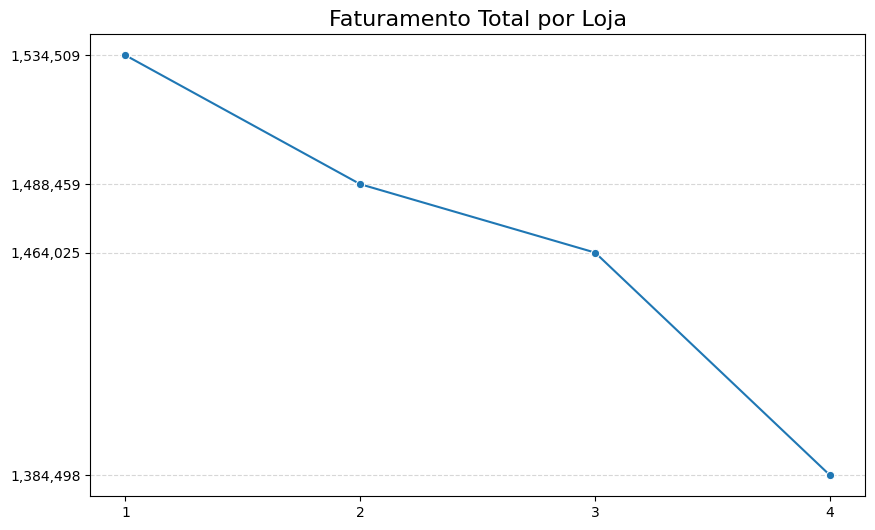

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

faturamento_por_loja = df_completo.groupby('Loja')['Faturamento Total'].sum()

plt.figure(figsize=(10, 6))
sns.lineplot(x=[label.replace('Loja ', '') for label in faturamento_por_loja.index], y=faturamento_por_loja.values, marker='o')
plt.title('Faturamento Total por Loja', fontsize=16)

y_values = faturamento_por_loja.values

plt.yticks(y_values)

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

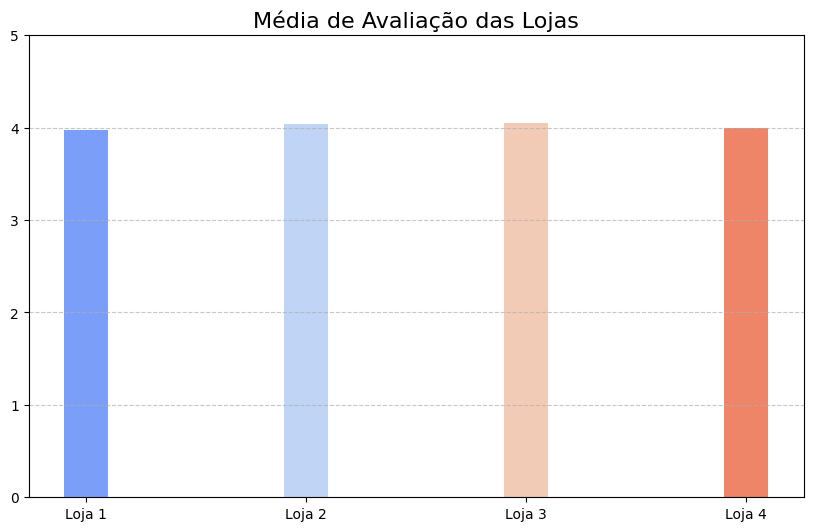

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
plt.bar(x=media_avaliacao_por_loja.index, height=media_avaliacao_por_loja.values, width=0.2, color=sns.color_palette('coolwarm', len(media_avaliacao_por_loja)))
plt.title('Média de Avaliação das Lojas', fontsize=16)
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

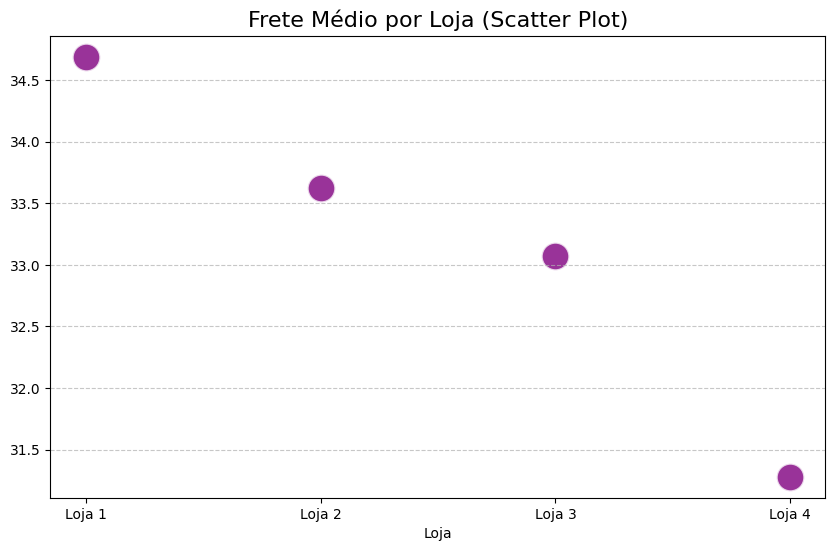

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.scatterplot(x=frete_medio_por_loja.index, y=frete_medio_por_loja.values, s=400, color='purple', alpha=0.8)

plt.title('Frete Médio por Loja (Scatter Plot)', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()